# Chapter 5: Bond and Stock Valuation

This atlas follows the lecture sequence and uses deterministic financial data so
that every code module can run without an internet connection.

## Learning map

1. APR, effective rates, and continuous compounding
2. Zero-coupon and coupon bond prices
3. Yield to maturity
4. Macaulay and modified duration
5. Dividend discount stock valuation

**Code availability:** Yes. Every code cell imports its own dependencies,
contains Chinese exam-oriented comments, and produces an interpretable result.

## How to Study This Chapter

- **First pass:** Read the concept and formula sections without running code.
- **Second pass:** Predict the output and fill in the commented key lines before execution.
- **Third pass:** Run each module independently and explain the result in one sentence.
- **Final review:** Compare related methods and identify when each method should or should not be used.

## Chapter Checklist

- Can I define every variable and state its unit?
- Can I reproduce the main formula or workflow without looking?
- Can I identify the code lines most likely to appear as blanks?
- Can I interpret the output economically or statistically?
- Can I name at least one common implementation error?


## 5.1 Effective Rates and APR Conversion

APR is a quoted annual rate. The effective annual rate reflects intra-year compounding: $EAR=(1+APR/m)^m-1$.


### Structured Review

- **Cash flows:** Separate coupon payments, face value, dividends, and terminal value.
- **Rate convention:** Identify APR, effective period rate, effective annual rate, or continuous rate before substitution.
- **Discounting:** Match the payment frequency with the discount-rate frequency.
- **Risk interpretation:** Connect YTM and duration to bond-price sensitivity.

### Key Relationships

- Higher YTM generally implies a lower bond price.
- A coupon rate above YTM generally produces a premium bond.
- Earlier or larger cash flows generally reduce duration.
- One basis point equals `0.0001`.

### Exam Focus

- Calculate coupon per period and total number of periods.
- Add face value only to the final coupon cash flow.
- Distinguish Macaulay duration from modified duration.

### Common Mistakes

- Multiplying or dividing YTM by frequency in the wrong direction.
- Forgetting the negative cash-flow convention in financial-library functions.
- Using current dividend instead of next-period dividend in terminal value.


In [1]:
'''
本单元实现 EAR、不同频率的有效利率和对应 APR。
利率频率转换必须保持同一年度增长因子不变。
'''
def effective_annual_rate(apr, frequency):
    # APR 除以频率得到每个复利期的有效利率
    return (1 + apr / frequency) ** frequency - 1

def equivalent_period_rate(apr1, frequency1, frequency2):
    # 先保持年度增长因子，再转换为目标频率下的单期利率
    return (1 + apr1 / frequency1) ** (frequency1 / frequency2) - 1

def equivalent_apr(apr1, frequency1, frequency2):
    # 目标 APR = 目标单期有效利率 × 目标频率
    return equivalent_period_rate(apr1, frequency1, frequency2) * frequency2

print("EAR =", round(effective_annual_rate(0.10, 2), 6))
print("Quarterly period rate =", round(equivalent_period_rate(0.10, 2, 4), 6))
print("Equivalent quarterly APR =", round(equivalent_apr(0.10, 2, 4), 6))


EAR = 0.1025
Quarterly period rate = 0.024695
Equivalent quarterly APR = 0.09878


**Result interpretation.** A 10% APR compounded semiannually has a 10.25% effective annual rate.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 5.2 Continuous Compounding

A discrete effective rate $R_m$ converts to a continuous annual rate using $R_c=m\ln(1+R_m)$.


### Structured Review

- **Cash flows:** Separate coupon payments, face value, dividends, and terminal value.
- **Rate convention:** Identify APR, effective period rate, effective annual rate, or continuous rate before substitution.
- **Discounting:** Match the payment frequency with the discount-rate frequency.
- **Risk interpretation:** Connect YTM and duration to bond-price sensitivity.

### Key Relationships

- Higher YTM generally implies a lower bond price.
- A coupon rate above YTM generally produces a premium bond.
- Earlier or larger cash flows generally reduce duration.
- One basis point equals `0.0001`.

### Exam Focus

- Calculate coupon per period and total number of periods.
- Add face value only to the final coupon cash flow.
- Distinguish Macaulay duration from modified duration.

### Common Mistakes

- Multiplying or dividing YTM by frequency in the wrong direction.
- Forgetting the negative cash-flow convention in financial-library functions.
- Using current dividend instead of next-period dividend in terminal value.


In [2]:
'''
本单元比较离散复利与连续复利终值。
正确转换后，两种计息方式应产生相同终值。
'''
from math import exp, log

def periodic_to_continuous(period_rate, frequency):
    # 连续年利率等于频率乘以单期增长因子的自然对数
    return frequency * log(1 + period_rate)

period_rate = 0.10
frequency = 1
years = 2
continuous_rate = periodic_to_continuous(period_rate, frequency)

discrete_fv = 100 * (1 + period_rate) ** (frequency * years)
continuous_fv = 100 * exp(continuous_rate * years)

print("Continuous rate =", round(continuous_rate, 6))
print("Discrete FV =", round(discrete_fv, 4))
print("Continuous FV =", round(continuous_fv, 4))


Continuous rate = 0.09531
Discrete FV = 121.0
Continuous FV = 121.0


**Result interpretation.** The future values match because the rate conversion preserves the growth factor.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 5.3 Zero-Coupon and Coupon Bond Pricing

A bond price equals the present value of coupons plus the present value of face value. A zero-coupon bond has only the final face-value cash flow.


### Structured Review

- **Cash flows:** Separate coupon payments, face value, dividends, and terminal value.
- **Rate convention:** Identify APR, effective period rate, effective annual rate, or continuous rate before substitution.
- **Discounting:** Match the payment frequency with the discount-rate frequency.
- **Risk interpretation:** Connect YTM and duration to bond-price sensitivity.

### Key Relationships

- Higher YTM generally implies a lower bond price.
- A coupon rate above YTM generally produces a premium bond.
- Earlier or larger cash flows generally reduce duration.
- One basis point equals `0.0001`.

### Exam Focus

- Calculate coupon per period and total number of periods.
- Add face value only to the final coupon cash flow.
- Distinguish Macaulay duration from modified duration.

### Common Mistakes

- Multiplying or dividing YTM by frequency in the wrong direction.
- Forgetting the negative cash-flow convention in financial-library functions.
- Using current dividend instead of next-period dividend in terminal value.


In [3]:
'''
本单元对零息债和附息债进行定价。
YTM 和票息支付次数必须转换为相同的每期频率。
'''
def zero_coupon_price(face_value, ytm, years, frequency=1):
    # 每期折现率为 ytm/frequency，总期数为 years*frequency
    return face_value / (1 + ytm / frequency) ** (years * frequency)

def coupon_bond_price(face_value, coupon_rate, ytm, years, frequency):
    periods = years * frequency
    coupon = face_value * coupon_rate / frequency
    price = 0.0

    for period in range(1, periods + 1):
        # 每一期票息都按对应期数折现
        price += coupon / (1 + ytm / frequency) ** period

    # 到期面值单独折现后加入债券价格
    price += face_value / (1 + ytm / frequency) ** periods
    return price

print("Zero-coupon price =", round(zero_coupon_price(1000, 0.05, 10, 2), 2))
print("Coupon bond price =", round(coupon_bond_price(1000, 0.08, 0.06, 10, 2), 2))


Zero-coupon price = 610.27
Coupon bond price = 1148.77


**Result interpretation.** The coupon bond sells above par because its coupon rate exceeds its YTM.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.

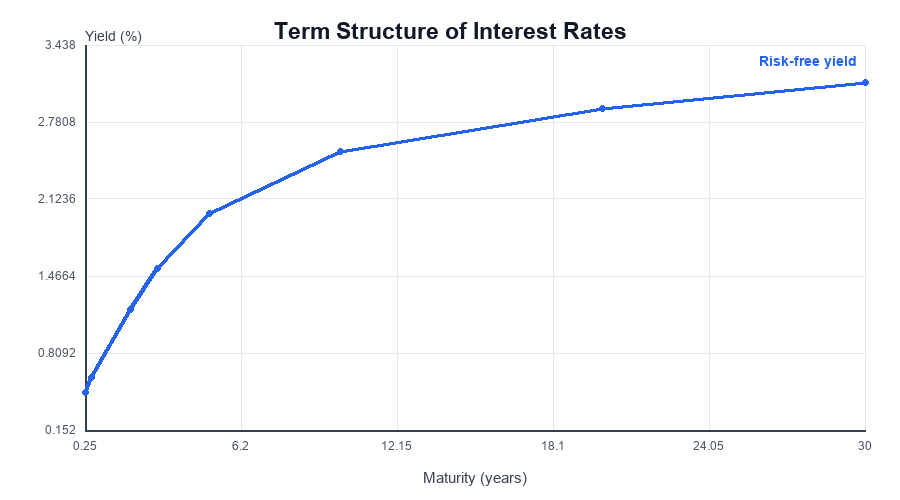


## 5.4 Yield to Maturity

YTM is the discount rate that equates the market price with the present value of promised bond cash flows.


### Structured Review

- **Purpose:** State what the code calculates and why the quantity matters in finance.
- **Inputs:** Identify the required data, parameter units, and expected data type.
- **Process:** Follow the transformation in execution order rather than reading only the final line.
- **Output:** Connect the printed value to an economic or statistical interpretation.

### Exam Focus

- Identify the lines most likely to be removed in a code-completion question.
- Trace dimensions, indices, and units through each intermediate variable.
- Use a small numerical example to check the direction and scale of the answer.

### Common Mistakes

- Reusing a variable with a different meaning.
- Depending on a previous notebook cell for an import or intermediate object.
- Reporting a number without explaining its financial meaning.


In [4]:
'''
本单元使用 numpy_financial.rate 反求债券每期收益率，再年化为名义 YTM。
现价使用负号，因为买入债券是当前现金流出。
'''
import numpy_financial as npf

face_value = 1000
market_price = 600
coupon_rate = 0.04
years = 10
frequency = 2

# 每期票息 = 面值 × 年票息率 ÷ 每年支付次数
coupon = face_value * coupon_rate / frequency

# rate 返回每个半年期的内部收益率
periodic_ytm = npf.rate(years * frequency, coupon, -market_price, face_value)

# 名义年化 YTM = 每期收益率 × 每年期数
annual_ytm = periodic_ytm * frequency

print("Periodic YTM =", f"{periodic_ytm:.4%}")
print("Annualized YTM =", f"{annual_ytm:.4%}")


Periodic YTM = 5.2888%
Annualized YTM = 10.5775%


**Result interpretation.** The deeply discounted bond has a YTM substantially above its 4% coupon rate.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 5.5 Macaulay and Modified Duration

Macaulay duration is the present-value-weighted average time of cash flows. Modified duration approximates percentage price sensitivity.


### Structured Review

- **Cash flows:** Separate coupon payments, face value, dividends, and terminal value.
- **Rate convention:** Identify APR, effective period rate, effective annual rate, or continuous rate before substitution.
- **Discounting:** Match the payment frequency with the discount-rate frequency.
- **Risk interpretation:** Connect YTM and duration to bond-price sensitivity.

### Key Relationships

- Higher YTM generally implies a lower bond price.
- A coupon rate above YTM generally produces a premium bond.
- Earlier or larger cash flows generally reduce duration.
- One basis point equals `0.0001`.

### Exam Focus

- Calculate coupon per period and total number of periods.
- Add face value only to the final coupon cash flow.
- Distinguish Macaulay duration from modified duration.

### Common Mistakes

- Multiplying or dividing YTM by frequency in the wrong direction.
- Forgetting the negative cash-flow convention in financial-library functions.
- Using current dividend instead of next-period dividend in terminal value.


In [5]:
'''
本单元逐期计算现金流现值权重，并得到 Macaulay 与修正久期。
最后一期现金流必须同时包含票息和面值。
'''
def bond_price_and_duration(face_value, coupon_rate, ytm, years, frequency):
    periods = years * frequency
    coupon = face_value * coupon_rate / frequency
    present_values = []
    times = []

    for period in range(1, periods + 1):
        # 最后一期现金流增加面值偿还
        cash_flow = coupon + (face_value if period == periods else 0)
        pv = cash_flow / (1 + ytm / frequency) ** period
        present_values.append(pv)
        times.append(period / frequency)

    price = sum(present_values)

    # 久期 = 各现金流时间 × 现值权重 的总和
    macaulay = sum(t * pv / price for t, pv in zip(times, present_values))

    # 修正久期用于近似价格百分比变化
    modified = macaulay / (1 + ytm / frequency)
    return price, macaulay, modified

price, macaulay, modified = bond_price_and_duration(1000, 0.07, 0.05, 10, 2)
estimated_change = -modified * 0.002

print("Price =", round(price, 2))
print("Macaulay duration =", round(macaulay, 4))
print("Modified duration =", round(modified, 4))
print("Estimated price change for +20 bps =", f"{estimated_change:.4%}")


Price = 1155.89
Macaulay duration = 7.5648
Modified duration = 7.3803
Estimated price change for +20 bps = -1.4761%


**Result interpretation.** The negative sign captures the inverse relation between bond price and yield.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.

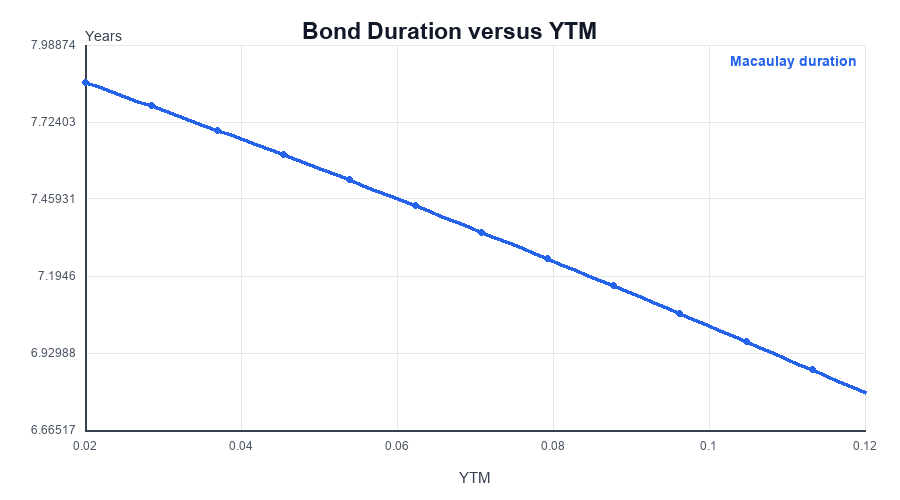


## 5.6 Multi-Stage Dividend Discount Model

Stock value equals the present value of forecast dividends plus the discounted terminal price, where $P_n=D_{n+1}/(r-g)$.


### Structured Review

- **Cash flows:** Separate coupon payments, face value, dividends, and terminal value.
- **Rate convention:** Identify APR, effective period rate, effective annual rate, or continuous rate before substitution.
- **Discounting:** Match the payment frequency with the discount-rate frequency.
- **Risk interpretation:** Connect YTM and duration to bond-price sensitivity.

### Key Relationships

- Higher YTM generally implies a lower bond price.
- A coupon rate above YTM generally produces a premium bond.
- Earlier or larger cash flows generally reduce duration.
- One basis point equals `0.0001`.

### Exam Focus

- Calculate coupon per period and total number of periods.
- Add face value only to the final coupon cash flow.
- Distinguish Macaulay duration from modified duration.

### Common Mistakes

- Multiplying or dividing YTM by frequency in the wrong direction.
- Forgetting the negative cash-flow convention in financial-library functions.
- Using current dividend instead of next-period dividend in terminal value.


In [6]:
'''
本单元计算有限预测期股利与终值的现值。
终值使用下一期股利，因此需要把最后一期股利乘以 (1+g)。
'''
def multi_stage_stock_value(dividends, required_return, perpetual_growth):
    explicit_value = 0.0

    for year, dividend in enumerate(dividends, start=1):
        # 每期股利按 required_return 折现回 0 期
        explicit_value += dividend / (1 + required_return) ** year

    # 终值位于最后一个预测期，分子是下一期股利
    next_dividend = dividends[-1] * (1 + perpetual_growth)
    terminal_value = next_dividend / (required_return - perpetual_growth)
    discounted_terminal = terminal_value / (1 + required_return) ** len(dividends)

    return explicit_value + discounted_terminal

dividends = [1.80, 2.07, 2.277, 2.48193, 2.680]
value = multi_stage_stock_value(dividends, 0.182, 0.03)
print("Estimated stock value =", round(value, 2))


Estimated stock value = 14.69


**Result interpretation.** Most of a growth stock's value may come from the terminal component, so the required return and growth assumptions matter greatly.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 5.7 Credit Spreads and the Price-YTM Relationship


Credit spreads are commonly quoted in basis points, where 100 basis points
equal one percentage point. A corporate yield can be approximated as the
risk-free yield plus a rating spread. Bond price moves inversely with YTM.



### Structured Review

- **Cash flows:** Separate coupon payments, face value, dividends, and terminal value.
- **Rate convention:** Identify APR, effective period rate, effective annual rate, or continuous rate before substitution.
- **Discounting:** Match the payment frequency with the discount-rate frequency.
- **Risk interpretation:** Connect YTM and duration to bond-price sensitivity.

### Key Relationships

- Higher YTM generally implies a lower bond price.
- A coupon rate above YTM generally produces a premium bond.
- Earlier or larger cash flows generally reduce duration.
- One basis point equals `0.0001`.

### Exam Focus

- Calculate coupon per period and total number of periods.
- Add face value only to the final coupon cash flow.
- Distinguish Macaulay duration from modified duration.

### Common Mistakes

- Multiplying or dividing YTM by frequency in the wrong direction.
- Forgetting the negative cash-flow convention in financial-library functions.
- Using current dividend instead of next-period dividend in terminal value.


In [7]:
'''
本单元补充老师源代码中的信用利差与价格-YTM关系。
1 个基点等于 0.0001，50 个基点等于 0.50%。
'''
def coupon_bond_price(face_value, coupon_rate, ytm, years, frequency):
    periods = years * frequency
    coupon = face_value * coupon_rate / frequency
    return sum(
        (coupon + (face_value if period == periods else 0))
        / (1 + ytm / frequency) ** period
        for period in range(1, periods + 1)
    )

risk_free_yield = 0.035
spread_basis_points = 50

# 基点转换为小数利率：除以 10,000
credit_spread = spread_basis_points / 10_000
corporate_ytm = risk_free_yield + credit_spread

ytm_values = [0.04, 0.05, 0.06, 0.07, corporate_ytm]
prices = [coupon_bond_price(1000, 0.06, ytm, 10, 2) for ytm in ytm_values]

print("Credit spread =", f"{credit_spread:.2%}")
print("Corporate YTM =", f"{corporate_ytm:.2%}")
for ytm, price in zip(ytm_values, prices):
    print(f"YTM={ytm:.2%}, price={price:.2f}")


Credit spread = 0.50%
Corporate YTM = 4.00%
YTM=4.00%, price=1163.51
YTM=5.00%, price=1077.95
YTM=6.00%, price=1000.00
YTM=7.00%, price=928.94
YTM=4.00%, price=1163.51


**Result interpretation.** As YTM increases, the present value of fixed bond cash flows falls. The basis-point conversion is essential when adding a credit spread.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.
